# Sanity check: σύγκριση MDVR feature extraction με UCI

Στόχος: να δούμε αν τα features που εξάγουμε με parselmouth από τα MDVR-KCL WAV αρχεία βρίσκονται σε λογικό εύρος σε σχέση με τα published features του UCI dataset.

**Δεν αλλάζουμε τίποτα εδώ.** Μόνο σύγκριση distributions.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

from src.features import extract_features, FEATURE_NAMES
from src.preprocessing import preprocess_audio

In [2]:
# Φόρτωση UCI published features
uci = pd.read_csv('../data/uci/pd_speech_features.csv', header=1)
uci_features = uci[FEATURE_NAMES].copy()
uci_features['source'] = 'UCI (published, Praat sustained /a/)'
print(f'UCI: {uci_features.shape}')

UCI: (756, 56)


In [3]:
# Extract MDVR με το δικό μας code, ΧΩΡΙΣ preprocessing (όπως είχαμε πριν)
MDVR_ROOT = Path('../data/mdvr_kcl/26-29_09_2017_KCL')
mdvr_files = list(MDVR_ROOT.rglob('*.wav'))
print(f'Found {len(mdvr_files)} MDVR WAV files')

mdvr_raw_rows = []
for wav in tqdm(mdvr_files[:20], desc='No preprocessing'):  # subset για ταχύτητα
    try:
        feats = extract_features(wav)
        mdvr_raw_rows.append(feats)
    except Exception as e:
        print(f'Error: {wav.name}: {e}')

mdvr_raw = pd.DataFrame(mdvr_raw_rows)
mdvr_raw['source'] = 'MDVR raw (no preprocessing)'
print(f'MDVR raw: {mdvr_raw.shape}')

Found 73 MDVR WAV files


No preprocessing:   0%|          | 0/20 [00:00<?, ?it/s]

No preprocessing:   5%|▌         | 1/20 [00:10<03:27, 10.94s/it]

No preprocessing:  10%|█         | 2/20 [00:13<01:43,  5.74s/it]

No preprocessing:  15%|█▌        | 3/20 [00:15<01:09,  4.10s/it]

...

No preprocessing:  90%|█████████ | 18/20 [00:40<00:03,  1.99s/it]

No preprocessing:  95%|█████████▌| 19/20 [00:43<00:02,  2.08s/it]

No preprocessing: 100%|██████████| 20/20 [00:45<00:00,  2.11s/it]

No preprocessing: 100%|██████████| 20/20 [00:45<00:00,  2.27s/it]

MDVR raw: (20, 56)


In [4]:
# Extract MDVR με το νέο preprocessing pipeline
import tempfile

mdvr_proc_rows = []
for wav in tqdm(mdvr_files[:20], desc='With preprocessing'):
    try:
        # Προεπεξεργασία
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            preprocess_audio(wav, output_path=tmp.name)
            feats = extract_features(tmp.name)
        mdvr_proc_rows.append(feats)
    except Exception as e:
        print(f'Error: {wav.name}: {e}')

mdvr_proc = pd.DataFrame(mdvr_proc_rows)
mdvr_proc['source'] = 'MDVR + preprocessing'
print(f'MDVR processed: {mdvr_proc.shape}')

With preprocessing:   0%|          | 0/20 [00:00<?, ?it/s]

With preprocessing:   5%|▌         | 1/20 [00:10<03:25, 10.82s/it]

With preprocessing:  10%|█         | 2/20 [00:13<01:47,  5.96s/it]

With preprocessing:  15%|█▌        | 3/20 [00:15<01:15,  4.42s/it]

With preprocessing:  20%|██        | 4/20 [00:18<00:56,  3.52s/it]

...

With preprocessing:  90%|█████████ | 18/20 [00:47<00:04,  2.41s/it]

With preprocessing:  95%|█████████▌| 19/20 [00:50<00:02,  2.61s/it]

With preprocessing: 100%|██████████| 20/20 [00:53<00:00,  2.68s/it]

With preprocessing: 100%|██████████| 20/20 [00:53<00:00,  2.68s/it]

MDVR processed: (20, 56)


## Σύγκριση distributions

In [5]:
key_features = [
    'locPctJitter', 'locShimmer', 'meanHarmToNoiseHarmonicity',
    'meanIntensity', 'f1', 'b1', 'mean_MFCC_0th_coef', 'mean_MFCC_6th_coef'
]

print(f'{"Feature":<30s} {"UCI mean (med)":<20s} {"MDVR raw":<20s} {"MDVR proc":<20s}')
print('-' * 90)
for f in key_features:
    u = uci_features[f]
    mr = mdvr_raw[f]
    mp = mdvr_proc[f] if f in mdvr_proc else None
    s_u = f'{u.mean():.4f} ({u.median():.4f})'
    s_mr = f'{mr.mean():.4f} ({mr.median():.4f})'
    s_mp = f'{mp.mean():.4f} ({mp.median():.4f})' if mp is not None else 'N/A'
    print(f'{f:<30s} {s_u:<20s} {s_mr:<20s} {s_mp:<20s}')

Feature                        UCI mean (med)       MDVR raw             MDVR proc           
------------------------------------------------------------------------------------------
locPctJitter                   0.0023 (0.0015)      0.0252 (0.0244)      0.0234 (0.0224)     
locShimmer                     0.0675 (0.0557)      0.1019 (0.0976)      0.1021 (0.0984)     
meanHarmToNoiseHarmonicity     18.8596 (19.3095)    6.9177 (9.5515)      6.9560 (9.1795)     
meanIntensity                  73.9970 (76.8553)    44.9848 (45.5313)    51.4109 (52.1806)   
f1                             647.1745 (641.1815)  676.3242 (653.7399)  696.6619 (644.4707) 
b1                             213.3632 (141.6110)  463.1221 (465.3244)  424.3013 (382.6958) 
mean_MFCC_0th_coef             14.9383 (15.0806)    -510.5783 (-507.0020) -420.7798 (-420.1710)
mean_MFCC_6th_coef             -1.1844 (-1.1728)    -0.1184 (-0.9423)    -0.9081 (-2.9043)   


/Users/georgegkikas/Documents/Health Technology Final/.venv/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


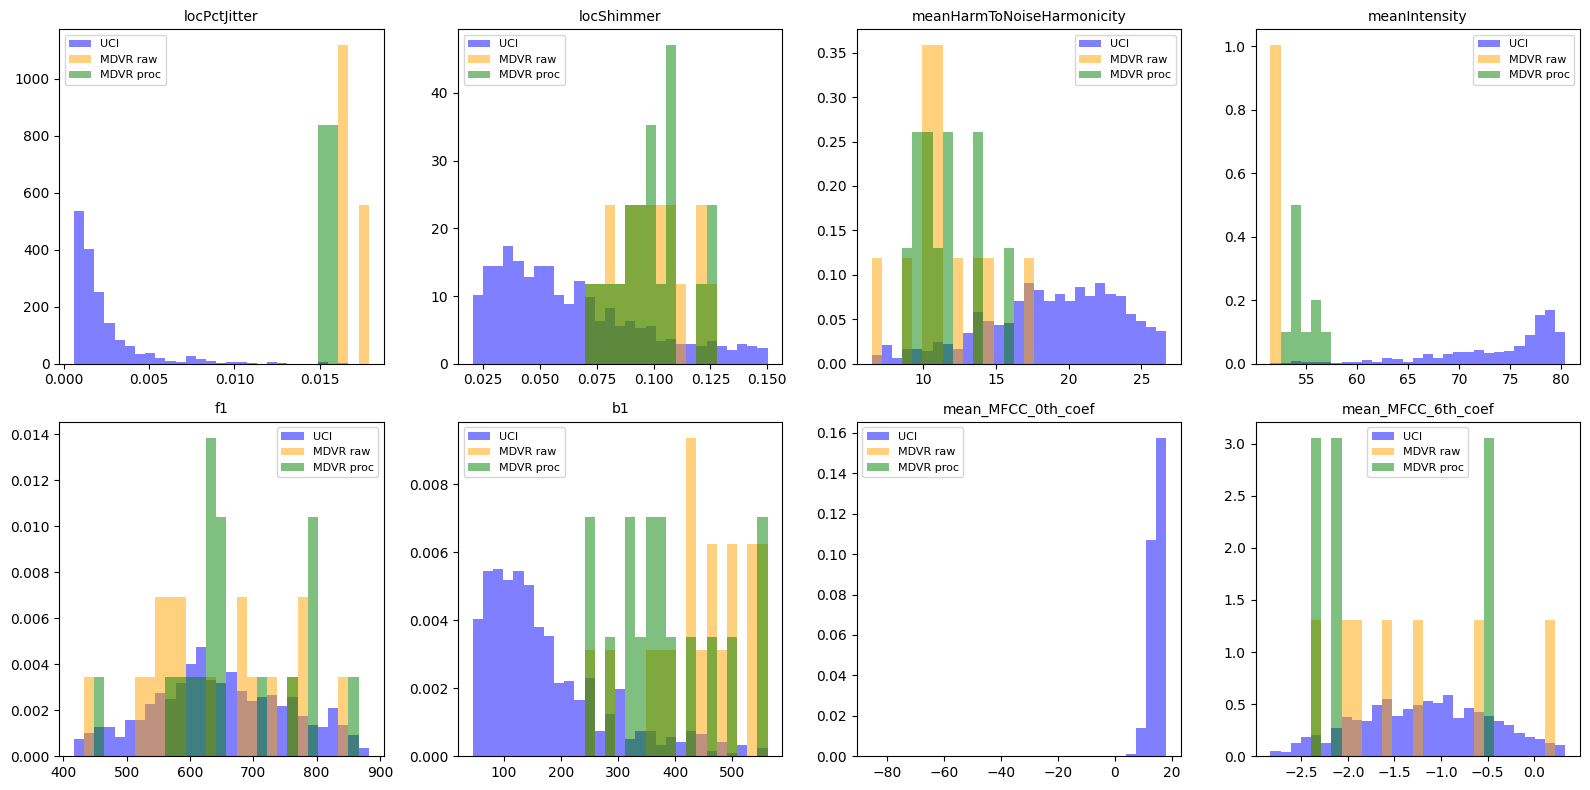

In [6]:
# Histograms για visual comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, f in zip(axes.flat, key_features):
    u = uci_features[f].dropna()
    mr = mdvr_raw[f].dropna()
    mp = mdvr_proc[f].dropna()
    
    # Κανονικοποίηση σε [0,1] για visual comparison
    all_vals = pd.concat([u, mr, mp])
    vmin, vmax = all_vals.quantile([0.05, 0.95])
    bins = np.linspace(vmin, vmax, 30)
    
    ax.hist(u, bins=bins, alpha=0.5, label='UCI', density=True, color='blue')
    ax.hist(mr, bins=bins, alpha=0.5, label='MDVR raw', density=True, color='orange')
    ax.hist(mp, bins=bins, alpha=0.5, label='MDVR proc', density=True, color='green')
    ax.set_title(f, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/feature_comparison.png', dpi=100)
plt.show()

## Συμπέρασμα

Αν το preprocessing φέρνει τα MDVR features πιο κοντά στα UCI distributions, το pipeline μας δουλεύει σωστά. Διαφορές που παραμένουν οφείλονται στο **task mismatch**:
- UCI: sustained vowel /a/ (σταθερό pitch, χαμηλό natural jitter)
- MDVR: reading text (προσωδιακή ποικιλία, αυξημένο natural jitter)

Δεν είναι extraction bug, είναι **φυσιολογική διαφορά εργασίας**. Άρα κάθε task χρειάζεται ξεχωριστό μοντέλο εκπαιδευμένο στο αντίστοιχο dataset.

## Feature exclusions ανά μοντέλο (τελική αρχιτεκτονική)

Με βάση τα ευρήματα της σύγκρισης παραπάνω, **διαφορετικά features εξαιρούνται σε κάθε μοντέλο**:

| Μοντέλο | Features | Πετιούνται | Λόγος |
|---------|----------|------------|-------|
| **UCI balanced** | 49 (από 55) | Intensity x3 + Harmonicity x3 (HNR/NHR/AutoCorr) | Scale mismatch: τα UCI features εξάγονται με Sakar protocol (άγνωστο σε εμάς). Τα intensity και HNR features έχουν διαφορετική κλίμακα από το δικό μας extraction. |
| **Iyer 8kHz** | 55 (όλα) | Κανένα | Εμείς extract-άρουμε με δικό μας pipeline → ίδια κλίμακα σε training και inference. |
| **MDVR** | 55 (όλα) | Κανένα | Όπως Iyer. |

**Mean MFCCs (13) και Bandwidths (4)**: ΔΕΝ τα έχουμε αφαιρέσει. Υπάρχουν `models/iyer_robust.joblib`, `mdvr_robust.joblib`, `uci_robust.joblib` από προηγούμενο πείραμα (notebook 04) που τα είχαν αφαιρέσει, αλλά τα current production μοντέλα τα κρατάνε. Σε μικρά datasets όπως Iyer (81), τα MFCC features είναι από τα πιο discriminative.

**HNR computation fix**: όλα τα μοντέλα χρησιμοποιούν `Sound.to_harmonicity_cc()` (cross-correlation) αντί του default `Sound.to_harmonicity_ac()`. Το AC default έδινε λάθος αρνητικές τιμές για clean audio. Με CC το HNR υπολογίζεται σωστά (15-25 dB για κανονική φωνή).
